# AqSolDB Applicability-Domain Analysis for Nutlin-3a Analogues

## Objective

This notebook evaluates whether the AqSolDB-derived logS model is being applied within a structurally relevant chemical domain for:

- Nutlin-3a
- Candidate 1

The analysis answers four questions:

1. Is Nutlin-3a present as an exact structure in the cleaned AqSolDB dataset?
2. Which AqSolDB compounds are most similar to Nutlin-3a and Candidate 1?
3. What are the maximum Morgan-fingerprint Tanimoto similarities?
4. Are Nutlin-like molecules sufficiently represented to support confident logS prediction?

## Scientific role

The results are used to interpret the uncertainty of the Generation 1 logS objective and to motivate the Generation 2 reward redesign.

Low structural similarity does not prove that a prediction is wrong. It indicates limited support from structurally related experimental examples.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator


PROJECT = Path.cwd()

# The notebook is expected to be stored in notebooks/.
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent

AQSOL_FILE = PROJECT / "data/processed/aqsoldb_cleaned.csv"

NUTLIN_FILE = (
    PROJECT
    / "data/reinvent/input/mol2mol_nutlin3a.smi"
)

CANDIDATE_FILE = (
    PROJECT
    / "outputs/reinvent/mdm2_logs_qed_similarity_pilot"
    / "temperature_analysis/final_candidates_pre_docking_table.csv"
)

OUTPUT_DIR = (
    PROJECT
    / "outputs/reward_calibration/aqsoldb_applicability_domain"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_FILE = OUTPUT_DIR / "nutlin_candidate1_aqsoldb_summary.csv"
NUTLIN_NEIGHBORS_FILE = OUTPUT_DIR / "nutlin3a_top20_aqsoldb_neighbors.csv"
CANDIDATE1_NEIGHBORS_FILE = OUTPUT_DIR / "candidate1_top20_aqsoldb_neighbors.csv"
SIMILARITY_DISTRIBUTION_FILE = OUTPUT_DIR / "aqsoldb_similarity_distributions.csv"
FIGURE_FILE = OUTPUT_DIR / "aqsoldb_similarity_histogram.png"

print("Project root:", PROJECT.resolve())
print("AqSolDB file exists:", AQSOL_FILE.exists())
print("Nutlin-3a file exists:", NUTLIN_FILE.exists())
print("Candidate table exists:", CANDIDATE_FILE.exists())
print("Output directory:", OUTPUT_DIR)


Project root: /Users/maryta/Downloads/mdm2_Reinvent_4_final
AqSolDB file exists: True
Nutlin-3a file exists: True
Candidate table exists: True
Output directory: /Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/reward_calibration/aqsoldb_applicability_domain


## 1. Load and inspect the cleaned AqSolDB dataset

In [3]:
if not AQSOL_FILE.exists():
    raise FileNotFoundError(AQSOL_FILE)

aqsol = pd.read_csv(AQSOL_FILE, low_memory=False)

print("Rows:", len(aqsol))
print("Columns:")
for column in aqsol.columns:
    print(" -", column)

aqsol.head()


Rows: 9349
Columns:
 - smiles
 - logS
 - logS_std
 - measurement_count
 - salt_removed
 - salt_record_count
 - maximum_original_fragment_count


,smiles,logS,logS_std,measurement_count,salt_removed,salt_record_count,maximum_original_fragment_count
0,B12B3B4B1C234,-4.742403,0.0,1,False,0,1
1,Br/C=C/Br,-1.741500,0.0,1,False,0,1
2,Br/C=C\Br,-1.319500,0.0,1,False,0,1
3,BrC(Br)(Br)Br,-3.140400,0.0,1,False,0,1
4,BrC(Br)Br,-1.911300,0.0,1,False,0,1


## 2. Detect the SMILES and measured logS columns

In [4]:
def detect_column(columns, candidates):
    lower_map = {
        str(column).lower(): column
        for column in columns
    }

    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    for candidate in candidates:
        for lower_column, original_column in lower_map.items():
            if candidate.lower() in lower_column:
                return original_column

    return None


smiles_column = detect_column(
    aqsol.columns,
    [
        "SMILES",
        "smiles",
        "canonical_smiles",
        "standardized_smiles",
    ],
)

logs_column = detect_column(
    aqsol.columns,
    [
        "Solubility",
        "solubility",
        "logS",
        "LogS",
        "measured_logS",
    ],
)

print("Detected SMILES column:", smiles_column)
print("Detected logS column:", logs_column)

if smiles_column is None:
    raise ValueError("Could not detect the AqSolDB SMILES column.")

if logs_column is None:
    raise ValueError("Could not detect the AqSolDB logS column.")


Detected SMILES column: smiles
Detected logS column: logS


## 3. Load Nutlin-3a and Candidate 1

In [9]:
if not NUTLIN_FILE.exists():
    raise FileNotFoundError(NUTLIN_FILE)

nutlin_smiles = (
    NUTLIN_FILE.read_text(encoding="utf-8")
    .strip()
    .splitlines()[0]
    .split()[0]
)

if not CANDIDATE_FILE.exists():
    raise FileNotFoundError(CANDIDATE_FILE)

candidate_table = pd.read_csv(CANDIDATE_FILE, low_memory=False)

required_candidate_columns = {"compound_label", "SMILES"}
missing = required_candidate_columns - set(candidate_table.columns)

if missing:
    raise ValueError(
        f"Missing candidate-table columns: {sorted(missing)}"
    )

candidate1_rows = candidate_table[
    candidate_table["compound_label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("candidate_1")
]

if len(candidate1_rows) != 1:
    raise ValueError(
        f"Expected exactly one Candidate_1 row, found {len(candidate1_rows)}."
    )

candidate1_smiles = candidate1_rows.iloc[0]["SMILES"]

references = pd.DataFrame(
    {
        "reference": ["Nutlin-3a", "Candidate 1"],
        "SMILES": [nutlin_smiles, candidate1_smiles],
    }
)

references


,reference,SMILES
0,Nutlin-3a,CC(C)OC1=C(C=CC(=C1)OC)C2=N[C@H]([C@H](N2C(=O)...
1,Candidate 1,COc1ccc(C2=N[C@@H](c3ccc(Cl)cc3)[C@@H](c3ccc(C...


## 4. Canonicalize structures and prepare the AqSolDB comparison set

In [7]:
def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None

    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def canonicalize(smiles):
    mol = mol_from_smiles(smiles)

    if mol is None:
        return None

    return Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=True,
    )


working = aqsol[[smiles_column, logs_column]].copy()

working[logs_column] = pd.to_numeric(
    working[logs_column],
    errors="coerce",
)

working["canonical_smiles"] = working[smiles_column].apply(
    canonicalize
)

working = (
    working
    .dropna(
        subset=[
            "canonical_smiles",
            logs_column,
        ]
    )
    .drop_duplicates(
        subset=["canonical_smiles"]
    )
    .reset_index(drop=True)
)

print("Usable unique AqSolDB molecules:", len(working))
working.head()


Usable unique AqSolDB molecules: 9349


,smiles,logS,canonical_smiles
0,B12B3B4B1C234,-4.742403,B12B3B4B1C234
1,Br/C=C/Br,-1.741500,Br/C=C/Br
2,Br/C=C\Br,-1.319500,Br/C=C\Br
3,BrC(Br)(Br)Br,-3.140400,BrC(Br)(Br)Br
4,BrC(Br)Br,-1.911300,BrC(Br)Br


## 5. Search for exact structural matches

In [10]:
references["canonical_smiles"] = references["SMILES"].apply(
    canonicalize
)

exact_match_rows = []

for _, reference_row in references.iterrows():
    reference_name = reference_row["reference"]
    reference_canonical = reference_row["canonical_smiles"]

    matches = working[
        working["canonical_smiles"] == reference_canonical
    ].copy()

    exact_match_rows.append(
        {
            "reference": reference_name,
            "exact_match_found": len(matches) > 0,
            "number_of_exact_matches": len(matches),
        }
    )

exact_match_summary = pd.DataFrame(exact_match_rows)
exact_match_summary


,reference,exact_match_found,number_of_exact_matches
0,Nutlin-3a,False,0
1,Candidate 1,False,0


## 6. Generate Morgan fingerprints

Fingerprint settings:

- radius: 2
- size: 2,048 bits
- chirality: included


In [11]:
fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048,
    includeChirality=True,
)


def fingerprint_from_smiles(smiles):
    mol = mol_from_smiles(smiles)

    if mol is None:
        return None

    return fp_generator.GetFingerprint(mol)


working["fingerprint"] = working[
    "canonical_smiles"
].apply(fingerprint_from_smiles)

working = working[
    working["fingerprint"].notna()
].reset_index(drop=True)

reference_fingerprints = {
    row["reference"]: fingerprint_from_smiles(row["SMILES"])
    for _, row in references.iterrows()
}

print("AqSolDB fingerprints generated:", len(working))


AqSolDB fingerprints generated: 9349


## 7. Calculate Tanimoto similarity to every AqSolDB molecule

In [12]:
similarity_tables = {}

for reference_name, reference_fp in reference_fingerprints.items():
    if reference_fp is None:
        raise ValueError(
            f"Could not generate a fingerprint for {reference_name}."
        )

    table = working[
        [
            smiles_column,
            "canonical_smiles",
            logs_column,
            "fingerprint",
        ]
    ].copy()

    table["tanimoto_similarity"] = [
        float(
            DataStructs.TanimotoSimilarity(
                reference_fp,
                fingerprint,
            )
        )
        for fingerprint in table["fingerprint"]
    ]

    table = (
        table
        .sort_values(
            "tanimoto_similarity",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    similarity_tables[reference_name] = table

print("Similarity calculations completed.")


Similarity calculations completed.


## 8. Inspect the 20 nearest AqSolDB neighbours

In [13]:
nutlin_top20 = (
    similarity_tables["Nutlin-3a"]
    .head(20)
    .drop(columns=["fingerprint"])
    .copy()
)

candidate1_top20 = (
    similarity_tables["Candidate 1"]
    .head(20)
    .drop(columns=["fingerprint"])
    .copy()
)

nutlin_top20.to_csv(
    NUTLIN_NEIGHBORS_FILE,
    index=False,
)

candidate1_top20.to_csv(
    CANDIDATE1_NEIGHBORS_FILE,
    index=False,
)

print("Nutlin-3a nearest neighbours")
display(nutlin_top20)

print("Candidate 1 nearest neighbours")
display(candidate1_top20)


Nutlin-3a nearest neighbours


,smiles,canonical_smiles,logS,tanimoto_similarity
0,CC(Oc1ccc(Cl)cc1)C(=O)O,CC(Oc1ccc(Cl)cc1)C(=O)O,-2.135100,0.250000
1,COc1ccc2cc(C(C)C(=O)OCCN3CCNCC3)ccc2c1,COc1ccc2cc(C(C)C(=O)OCCN3CCNCC3)ccc2c1,-1.520000,0.250000
2,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,-4.770000,0.250000
3,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1,COC(=O)C(C)Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1,-3.834000,0.243902
4,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,-3.703093,0.238095
5,CC(Oc1ccc(Oc2ncc(Cl)cc2Cl)cc1)C(=O)N1CCCO1,CC(Oc1ccc(Oc2ncc(Cl)cc2Cl)cc1)C(=O)N1CCCO1,-4.592200,0.236559
6,CC(Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1)C(=O)O,CC(Oc1ccc(Oc2ccc(Cl)cc2Cl)cc1)C(=O)O,-5.040000,0.234568
7,COc1ccc2cc(C(C)C(=O)OC(C)C)ccc2c1,COc1ccc2cc(C(C)C(=O)OC(C)C)ccc2c1,-5.480000,0.227848
8,COc1ccc2cc(C(C)C(=O)OCCN3CCN(C)CC3)ccc2c1,COc1ccc2cc(C(C)C(=O)OCCN3CCN(C)CC3)ccc2c1,-1.490000,0.227273
9,COc1ccc(Cl)cc1,COc1ccc(Cl)cc1,-2.779325,0.227273


Candidate 1 nearest neighbours


,smiles,canonical_smiles,logS,tanimoto_similarity
0,COc1ccc2cc(C(C)C(=O)OCCN3CCN(C)CC3)ccc2c1,COc1ccc2cc(C(C)C(=O)OCCN3CCN(C)CC3)ccc2c1,-1.490000,0.289474
1,COc1ccc(OC)c(Cl)c1,COc1ccc(OC)c(Cl)c1,-2.672402,0.288136
2,COc1ccc2cc(C(C)C(=O)OCCCCN3CCN(C)CC3)ccc2c1,COc1ccc2cc(C(C)C(=O)OCCCCN3CCN(C)CC3)ccc2c1,-1.290000,0.278481
3,COc1ccc(Cl)cc1,COc1ccc(Cl)cc1,-2.779325,0.267857
4,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,-4.770000,0.265823
5,COc1cc(Oc2ccc(Cl)cc2Cl)ccc1[N+](=O)[O-],COc1cc(Oc2ccc(Cl)cc2Cl)ccc1[N+](=O)[O-],-5.910000,0.260274
6,COc1ccc(OC)c(NC(C)=O)c1,COc1ccc(OC)c(NC(C)=O)c1,-1.591550,0.257576
7,CN1CCN(C2=Nc3ccccc3Oc3ccc(Cl)cc32)CC1,CN1CCN(C2=Nc3ccccc3Oc3ccc(Cl)cc32)CC1,-4.420000,0.250000
8,CCC(=O)C(CCCCCCOc1ccc(OC)cc1Cl)C(=O)CC,CCC(=O)C(CCCCCCOc1ccc(OC)cc1Cl)C(=O)CC,-5.270000,0.246753
9,CN1CCN(C2=Nc3cc(Cl)ccc3Nc3ccccc32)CC1,CN1CCN(C2=Nc3cc(Cl)ccc3Nc3ccccc32)CC1,-4.640000,0.246753


## 9. Summarize applicability-domain coverage

In [14]:
summary_rows = []

for reference_name, table in similarity_tables.items():
    similarities = table["tanimoto_similarity"]

    exact_match_found = bool(
        exact_match_summary.loc[
            exact_match_summary["reference"] == reference_name,
            "exact_match_found",
        ].iloc[0]
    )

    maximum_similarity = float(similarities.max())

    if maximum_similarity >= 0.70:
        coverage_class = "high"
    elif maximum_similarity >= 0.50:
        coverage_class = "moderate"
    elif maximum_similarity >= 0.30:
        coverage_class = "low"
    else:
        coverage_class = "very low"

    top10 = table.head(10)

    weighted_logs = np.average(
        top10[logs_column],
        weights=top10["tanimoto_similarity"],
    )

    summary_rows.append(
        {
            "reference": reference_name,
            "exact_match_found": exact_match_found,
            "maximum_tanimoto_similarity": maximum_similarity,
            "neighbors_similarity_gt_0.50": int(
                (similarities > 0.50).sum()
            ),
            "neighbors_similarity_gt_0.30": int(
                (similarities > 0.30).sum()
            ),
            "top10_mean_measured_logS": float(
                top10[logs_column].mean()
            ),
            "top10_median_measured_logS": float(
                top10[logs_column].median()
            ),
            "top10_similarity_weighted_logS": float(
                weighted_logs
            ),
            "coverage_class": coverage_class,
        }
    )

summary = pd.DataFrame(summary_rows)
summary.to_csv(SUMMARY_FILE, index=False)

summary


,reference,exact_match_found,maximum_tanimoto_similarity,neighbors_similarity_gt_0.50,neighbors_similarity_gt_0.30,top10_mean_measured_logS,top10_median_measured_logS,top10_similarity_weighted_logS,coverage_class
0,Nutlin-3a,False,0.250000,0,0,-3.534372,-3.768546,-3.525667,very low
1,Candidate 1,False,0.289474,0,0,-3.483328,-3.599663,-3.421752,very low


## 10. Plot the full similarity distributions

The histogram shows how strongly the reference molecules are represented across the full AqSolDB chemical space.

A distribution concentrated at low similarity indicates weak structural coverage.


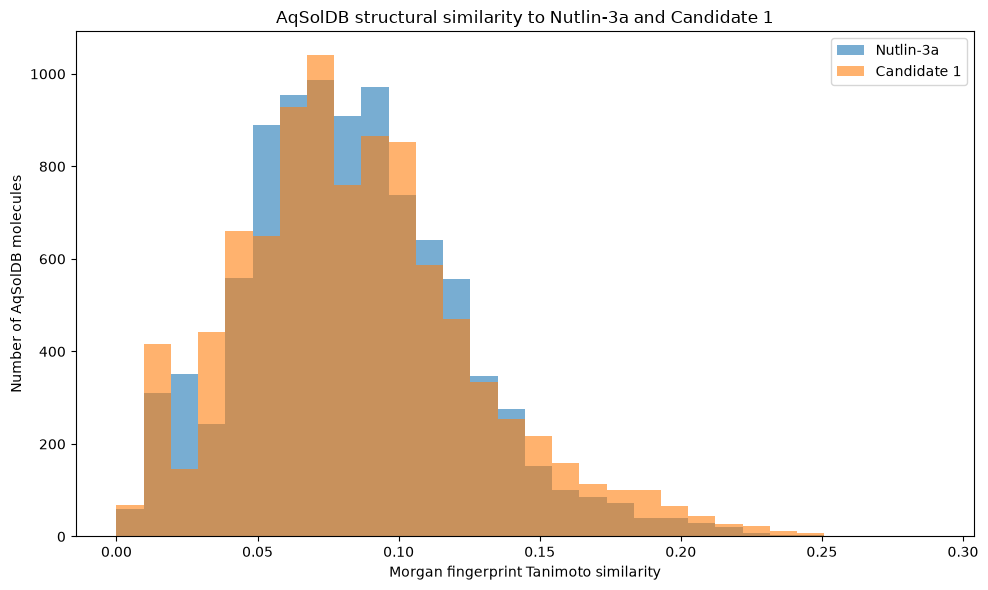

Saved figure: /Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/reward_calibration/aqsoldb_applicability_domain/aqsoldb_similarity_histogram.png


In [15]:
distribution = pd.DataFrame(
    {
        "Nutlin-3a": similarity_tables[
            "Nutlin-3a"
        ]["tanimoto_similarity"].to_numpy(),
        "Candidate 1": similarity_tables[
            "Candidate 1"
        ]["tanimoto_similarity"].to_numpy(),
    }
)

distribution.to_csv(
    SIMILARITY_DISTRIBUTION_FILE,
    index=False,
)

ax = distribution.plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    figsize=(10, 6),
)

ax.set_xlabel("Morgan fingerprint Tanimoto similarity")
ax.set_ylabel("Number of AqSolDB molecules")
ax.set_title(
    "AqSolDB structural similarity to Nutlin-3a and Candidate 1"
)

plt.tight_layout()
plt.savefig(
    FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved figure:", FIGURE_FILE)


## 11. Inspect similarity-threshold counts

In [16]:
thresholds = [0.20, 0.25, 0.30, 0.40, 0.50, 0.70]

threshold_rows = []

for reference_name, table in similarity_tables.items():
    for threshold in thresholds:
        threshold_rows.append(
            {
                "reference": reference_name,
                "threshold": threshold,
                "number_of_molecules_above_threshold": int(
                    (
                        table["tanimoto_similarity"]
                        >= threshold
                    ).sum()
                ),
            }
        )

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.pivot(
    index="threshold",
    columns="reference",
    values="number_of_molecules_above_threshold",
)


reference,Candidate 1,Nutlin-3a
threshold,,
0.20,142,82
0.25,8,3
0.30,0,0
0.40,0,0
0.50,0,0
0.70,0,0


## 12. Scientific interpretation

Use the calculated values in the summary table rather than relying on memory.

Recommended interpretation:

- If no exact match is found, the reference structure is absent from the cleaned AqSolDB dataset.
- A maximum Tanimoto similarity below 0.30 indicates very weak structural coverage.
- A maximum similarity between 0.30 and 0.50 indicates low coverage.
- A lack of neighbours above 0.50 means that no close analogues were identified under the chosen fingerprint representation.

This does not prove that the logS prediction is incorrect.

It indicates that the prediction has limited support from structurally related experimental compounds and should therefore be interpreted with increased uncertainty.


## 13. Motivation for Generation 2

Generation 1 assigned 25% of the reward to predicted logS.

If Nutlin-3a and Candidate 1 show only very low nearest-neighbour similarity to AqSolDB compounds, the logS objective has weak applicability-domain support for this scaffold family.

This motivates the following Generation 2 changes:

- reduce the relative influence of the AqSolDB-derived logS objective,
- avoid treating logS as a highly confident optimization target,
- include an applicability-domain warning or constraint,
- incorporate selected ADMET-AI endpoints,
- retain predicted MDM2 activity as the primary positive objective.

The Generation 2 reward should be redesigned using both:

- the applicability-domain analysis in this notebook,
- the ADMET comparison in `notebooks/15_generation1_admet_comparison.ipynb`.


## 14. Saved outputs

In [17]:
print("Summary:")
print(SUMMARY_FILE)

print("\nNutlin-3a top 20 neighbours:")
print(NUTLIN_NEIGHBORS_FILE)

print("\nCandidate 1 top 20 neighbours:")
print(CANDIDATE1_NEIGHBORS_FILE)

print("\nFull similarity distributions:")
print(SIMILARITY_DISTRIBUTION_FILE)

print("\nHistogram:")
print(FIGURE_FILE)


Summary:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/reward_calibration/aqsoldb_applicability_domain/nutlin_candidate1_aqsoldb_summary.csv

Nutlin-3a top 20 neighbours:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/reward_calibration/aqsoldb_applicability_domain/nutlin3a_top20_aqsoldb_neighbors.csv

Candidate 1 top 20 neighbours:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/reward_calibration/aqsoldb_applicability_domain/candidate1_top20_aqsoldb_neighbors.csv

Full similarity distributions:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/reward_calibration/aqsoldb_applicability_domain/aqsoldb_similarity_distributions.csv

Histogram:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/reward_calibration/aqsoldb_applicability_domain/aqsoldb_similarity_histogram.png


## Conclusion template

After running the notebook, replace the values below with the calculated results:

> No exact Nutlin-3a match was found in the cleaned AqSolDB dataset. The maximum Morgan-fingerprint Tanimoto similarity was approximately **0.25** for Nutlin-3a and **0.29** for Candidate 1. No neighbours above **0.30** were identified for either reference. These results indicate **very low** structural coverage of the Nutlin-like scaffold family within AqSolDB. Therefore, the corresponding logS predictions should be interpreted with increased applicability-domain uncertainty.